In [ ]:
import numpy as np
import torch
import time
import csv
import matplotlib.pyplot as plt
import random

# this functions parses a csv files
# it works roughly the same as the function in the KNN implemention, but the classes
# are changed from 1-based to 0-based, as this simplifies the training process
def parse_csv(file_path):
    with open(file_path, 'r') as f:
        r = csv.reader(f)
        x_values = []
        y_values = []
        for row in r:
            # convert to numpy array
            features = np.array([float(x) for x in row[:-1]])
            # change to 0-based from 1-based
            c = int(float(row[-1])) - 1
            x_values.append(features)
            y_values.append(c)
    # pytorch expect classes to be in np.int64
    return np.array(x_values, dtype=np.float32), np.array(y_values, dtype=np.int64)


In [ ]:
# Helper class to quickly define an MLP
class Network(torch.nn.Module):
    # create a fully customizalbe feedforward MLP
    # input_size: number of neurons in the first layer
    # hidden_layers: array of the neurons of the given hidden layers. The activation functions will be ReLu
    # output_size: number of neurons in the output layer
    def __init__(self, input_size, hidden_layers, output_size):
        super(Network, self).__init__()
        layers = []
        in_features = input_size

        # Add hidden layers
        for h_size in hidden_layers:
            layers.append(torch.nn.Linear(in_features, h_size))
            layers.append(torch.nn.ReLU())
            in_features = h_size

        # Add output layer
        layers.append(torch.nn.Linear(in_features, output_size))

        # to create the network, make an sequential block
        self.model = torch.nn.Sequential(*layers)

    # forward pass for the model
    def forward(self, x):
        return self.model(x)

In [ ]:
# simple pytorch training loop
# model: the model to train
# input: the input of the model
# labels: the labels for the given inputs, must be the same size as input
# test_inputs: input to later find out the accuarcy on unknown data
# test_labels: the label for the test_inputs
# num_epochs: number of epochs to train
# lr: the learinng rate for the optimizer
def train_model(model, inputs, labels, test_inputs, test_labels, num_epochs, lr=0.01):
    start_time = time.time()
    epoch_accuracies = []

    # for classfication crossentropyloss is recommonded
    criterion = torch.nn.CrossEntropyLoss()
    # adam optimizer to tune the model
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # training loop
    for epoch in range(num_epochs):
        # get the predictions from the model
        outputs = model(inputs)
        # calculate the loss with the given labesl
        loss = criterion(outputs, labels)

        # reset gradient
        optimizer.zero_grad()
        # to a backwards pass to calculate the gradient
        loss.backward()
        # change weights in the direction of the gradient
        optimizer.step()

        # Find out the accuarcy of the model in this epoch
        # to improve performance, the calculation of the gradient will be disabled
        with torch.no_grad():
            # run inference
            test_outputs = model(test_inputs)
            # get predietec class for the inputs
            _, predicted = torch.max(test_outputs, 1)
            # accuarcy is amout of correct samplems
            accuracy = (predicted == test_labels).sum().item() / len(test_labels)

        # saved for later
        epoch_accuracies.append(accuracy*100.0)

        # we don't want to print every epoch
        if (epoch+1) % 10 == 0:
          print(f"Epoch [{epoch+1}/{num_epochs}] Accuracy: {accuracy*100:.2f}%")

    # Synchronize GPU before stopping timer
    if inputs.device.type == "cuda":
        torch.cuda.synchronize()

    # stop the timer
    training_time = time.time() - start_time
    return training_time, epoch_accuracies

In [ ]:
# helper function to make data gathering about the model easier
# device: the device on which everything should run
# layer: the structure of the hidden layers in the network
# num_epochs: the maxium number of epochs to train for
def run_train_and_val(device, layers=[10], num_epochs=200):
    # to always get the same random init weights for a model
    # the random generators are seeded
    torch.manual_seed(42)
    random.seed(42)
    # load the data
    x_val, y_val = parse_csv('MLoGPU_data3_train.csv')
    # split into train and test data
    # (not randonmizazion to have reproducitbily)
    split_index = int(0.7 * len(x_val))
    x_train, y_train = x_val[:split_index], y_val[:split_index]
    x_test, y_test = x_val[split_index:], y_val[split_index:]

    # create the model and move it to the given device
    model = Network(7, layers, 7).to(device)

    # convert all data into torch tensors
    inputs = torch.from_numpy(x_train).to(device)
    labels = torch.from_numpy(y_train).to(device)
    test_inputs = torch.from_numpy(x_test).to(device)
    test_labels = torch.from_numpy(y_test).to(device)

    # to the training with validations
    training_time, epoch_accuracies = train_model(
        model,
        inputs,
        labels,
        test_inputs,
        test_labels,
        num_epochs
    )

    # returns results
    return max(epoch_accuracies), training_time, epoch_accuracies, x_test

In [ ]:
cpu_acc, cpu_time, cpu_curve, cpu_x_test = run_train_and_val("cpu")
gpu_acc, gpu_time, gpu_curve, gpu_x_test = run_train_and_val("cuda")


print("CPU accuracy:", cpu_acc)
print("GPU accuracy:", gpu_acc)
print("CPU training time:", cpu_time)
print("GPU training time:", gpu_time)

Epoch [10/200] Accuracy: 25.08%
Epoch [20/200] Accuracy: 47.75%
Epoch [30/200] Accuracy: 49.33%
Epoch [40/200] Accuracy: 50.25%
Epoch [50/200] Accuracy: 50.58%
Epoch [60/200] Accuracy: 51.25%
Epoch [70/200] Accuracy: 53.00%
Epoch [80/200] Accuracy: 53.33%
Epoch [90/200] Accuracy: 54.67%
Epoch [100/200] Accuracy: 54.83%
Epoch [110/200] Accuracy: 54.83%
Epoch [120/200] Accuracy: 55.00%
Epoch [130/200] Accuracy: 55.08%
Epoch [140/200] Accuracy: 55.25%
Epoch [150/200] Accuracy: 55.42%
Epoch [160/200] Accuracy: 55.42%
Epoch [170/200] Accuracy: 55.17%
Epoch [180/200] Accuracy: 55.17%
Epoch [190/200] Accuracy: 54.58%
Epoch [200/200] Accuracy: 54.67%
Epoch [10/200] Accuracy: 25.08%
Epoch [20/200] Accuracy: 47.75%
Epoch [30/200] Accuracy: 49.33%
Epoch [40/200] Accuracy: 50.25%
Epoch [50/200] Accuracy: 50.58%
Epoch [60/200] Accuracy: 51.25%
Epoch [70/200] Accuracy: 53.00%
Epoch [80/200] Accuracy: 53.33%
Epoch [90/200] Accuracy: 54.67%
Epoch [100/200] Accuracy: 54.83%
Epoch [110/200] Accuracy: 54

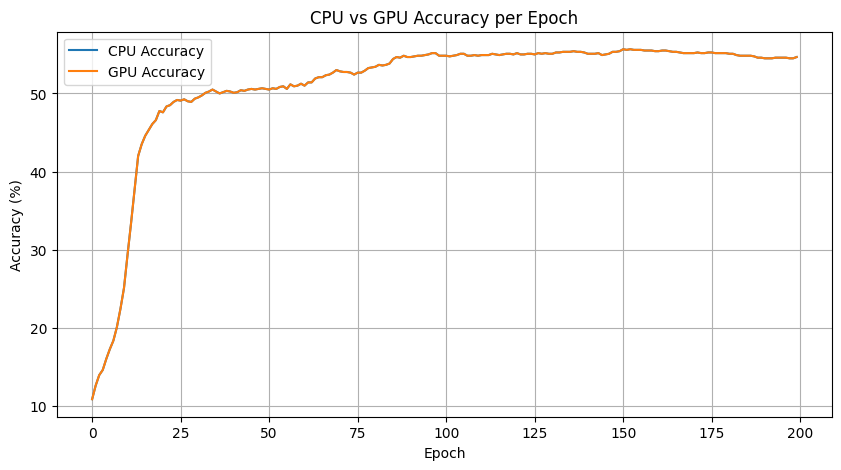

In [ ]:
# Plot the accuries over epochs
plt.figure(figsize=(10,5))
plt.plot(cpu_curve, label="CPU Accuracy")
plt.plot(gpu_curve, label="GPU Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("CPU vs GPU Accuracy per Epoch")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# to do more measurement, this functions is used
# it runs in a tight loop and mea
def measure_inference_time(model, inputs, device, runs=50):
    model.eval()
    inputs = inputs.to(device)

    # Warm-up (important for GPU)
    for _ in range(10):
        with torch.no_grad():
            _ = model(inputs)
    if device == "cuda":
        torch.cuda.synchronize()

    # Actual timing
    start = time.time()
    for _ in range(runs):
        with torch.no_grad():
            _ = model(inputs)
    if device == "cuda":
        torch.cuda.synchronize()
    end = time.time()

    return (end - start) / runs

In [ ]:
# Prepare a single test sample for CPU
sample_cpu = torch.from_numpy(np.expand_dims(cpu_x_test[0], axis=0)).float()

hidden_layers = [10]

# CPU model
model_cpu = Network(7, hidden_layers, 7).to("cpu")
cpu_inference = measure_inference_time(model_cpu, sample_cpu, "cpu")

# Prepare a single test sample for GPU
sample_gpu = torch.from_numpy(np.expand_dims(gpu_x_test[0], axis=0)).float()

# GPU model
model_gpu = Network(7, hidden_layers, 7).to("cuda")
gpu_inference = measure_inference_time(model_gpu, sample_gpu, "cuda")

print("CPU inference time:", cpu_inference)
print("GPU inference time:", gpu_inference)

CPU inference time: 7.120132446289062e-05
GPU inference time: 0.00010262966156005859


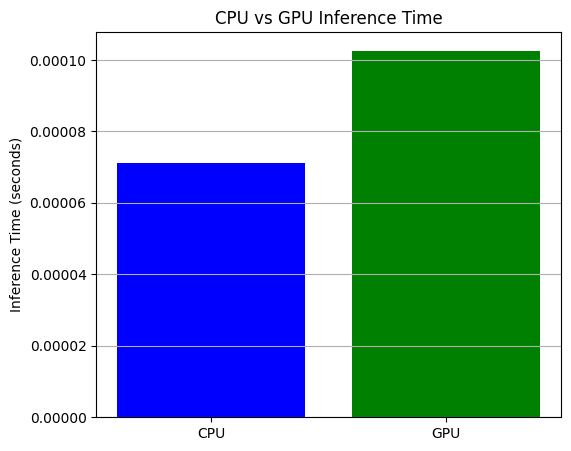

In [ ]:
plt.figure(figsize=(6,5))
plt.bar(["CPU", "GPU"], [cpu_inference, gpu_inference], color=["blue", "green"])
plt.ylabel("Inference Time (seconds)")
plt.title("CPU vs GPU Inference Time")
plt.grid(axis="y")
plt.show()


In [ ]:
# to run larger tests on GPU efficency
# here we define three different models
# the sizes are chosen by guessing
configs = [
    {'name': 'Simple (1x10)', 'layers': [10]},
    {'name': 'Medium (3x20)', 'layers': [20, 20, 20]},
    {'name': 'Large (10x50)', 'layers': [50, 50, 50, 50, 50, 50, 50, 50, 50, 50]}
]

batch_sizes = [1, 8, 32, 128, 512, 2048]
results = {}

# in this loop we go through every network config and measure the time it takes
# for a given batch size to be classied
# the model is not trained, however this does not influce the batch size
for config in configs:
    name = config['name']
    layers = config['layers']

    # one network for GPU one for CPU
    m_cpu = Network(7, layers, 7).to('cpu')
    m_gpu = Network(7, layers, 7).to('cuda')

    cpu_times = []
    gpu_times = []

    for b in batch_sizes:
        # create random input data
        data = torch.randn(b, 7).float()
        cpu_times.append(measure_inference_time(m_cpu, data, 'cpu'))
        gpu_times.append(measure_inference_time(m_gpu, data, 'cuda'))

    results[name] = {'cpu': cpu_times, 'gpu': gpu_times}

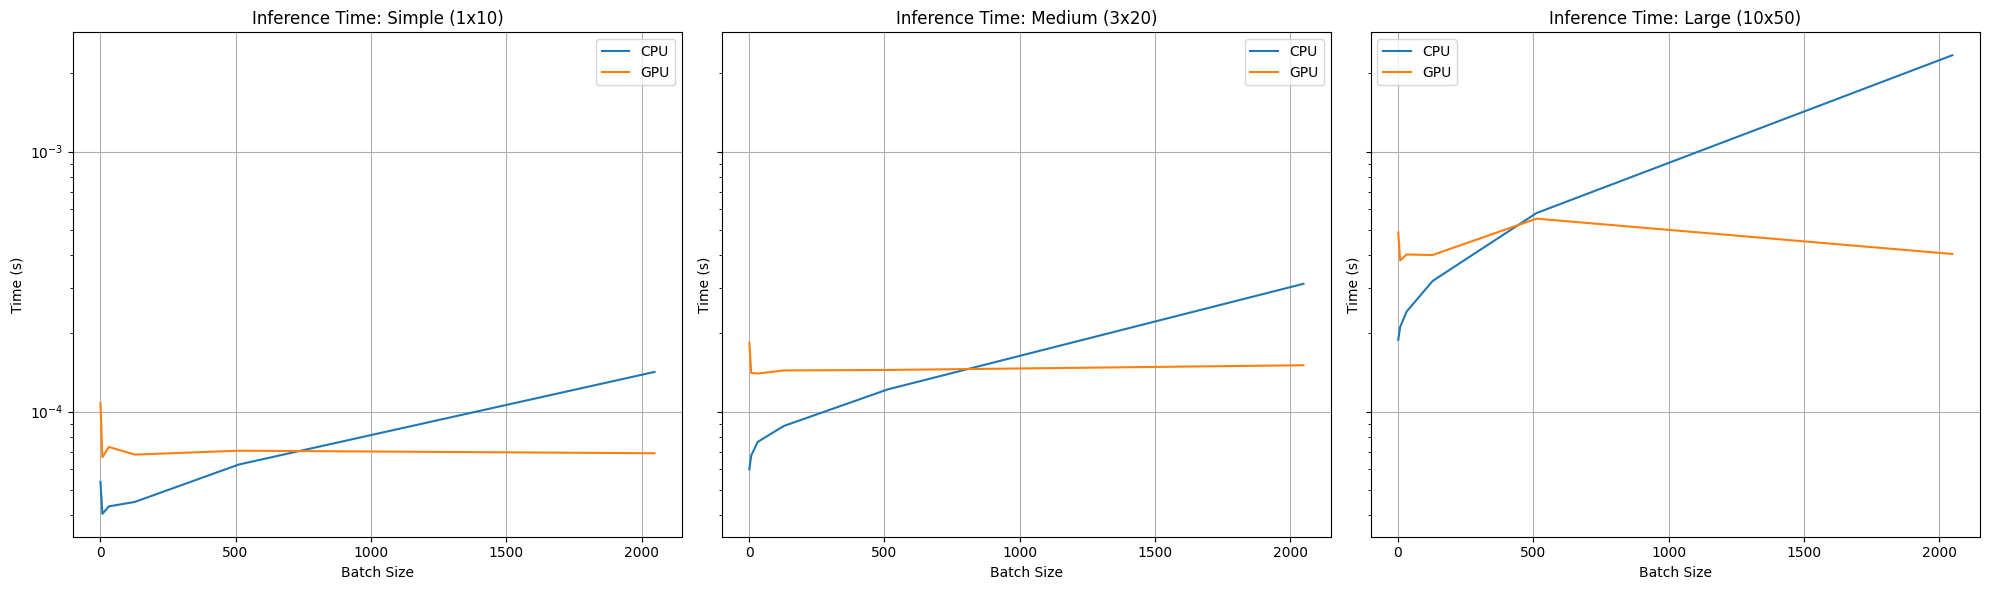

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

for i, config in enumerate(configs):
    name = config['name']
    ax = axes[i]

    ax.plot(batch_sizes, results[name]['cpu'], label='CPU')
    ax.plot(batch_sizes, results[name]['gpu'], label='GPU')

    ax.set_title(f'Inference Time: {name}')
    ax.set_xlabel('Batch Size')
    ax.set_ylabel('Time (s)')
    ax.set_yscale('log')
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
training_results = {}
accuracy_results = {}
num_epochs = 50

# here we interate throught the config and get the accuries for each model and the training time
for config in configs:
    name = config['name']
    layers = config['layers']
    # Run GPU training
    acc_gpu, gpu_t, curve_gpu, _ = run_train_and_val('cuda', layers=layers, num_epochs=num_epochs)

    # Run CPU training
    acc_cpu, cpu_t, curve_cpu, _ = run_train_and_val('cpu', layers=layers, num_epochs=num_epochs)

    # Store results
    training_results[name] = {'cpu': cpu_t, 'gpu': gpu_t}
    accuracy_results[name] = curve_gpu

Epoch [10/50] Accuracy: 25.08%
Epoch [20/50] Accuracy: 47.75%
Epoch [30/50] Accuracy: 49.33%
Epoch [40/50] Accuracy: 50.25%
Epoch [50/50] Accuracy: 50.58%
Epoch [10/50] Accuracy: 25.08%
Epoch [20/50] Accuracy: 47.75%
Epoch [30/50] Accuracy: 49.33%
Epoch [40/50] Accuracy: 50.25%
Epoch [50/50] Accuracy: 50.58%
Epoch [10/50] Accuracy: 44.42%
Epoch [20/50] Accuracy: 47.08%
Epoch [30/50] Accuracy: 51.50%
Epoch [40/50] Accuracy: 52.25%
Epoch [50/50] Accuracy: 53.00%
Epoch [10/50] Accuracy: 44.42%
Epoch [20/50] Accuracy: 47.08%
Epoch [30/50] Accuracy: 51.50%
Epoch [40/50] Accuracy: 52.25%
Epoch [50/50] Accuracy: 53.00%
Epoch [10/50] Accuracy: 33.58%
Epoch [20/50] Accuracy: 44.42%
Epoch [30/50] Accuracy: 44.42%
Epoch [40/50] Accuracy: 44.42%
Epoch [50/50] Accuracy: 44.42%
Epoch [10/50] Accuracy: 33.58%
Epoch [20/50] Accuracy: 44.42%
Epoch [30/50] Accuracy: 44.42%
Epoch [40/50] Accuracy: 44.42%
Epoch [50/50] Accuracy: 44.42%


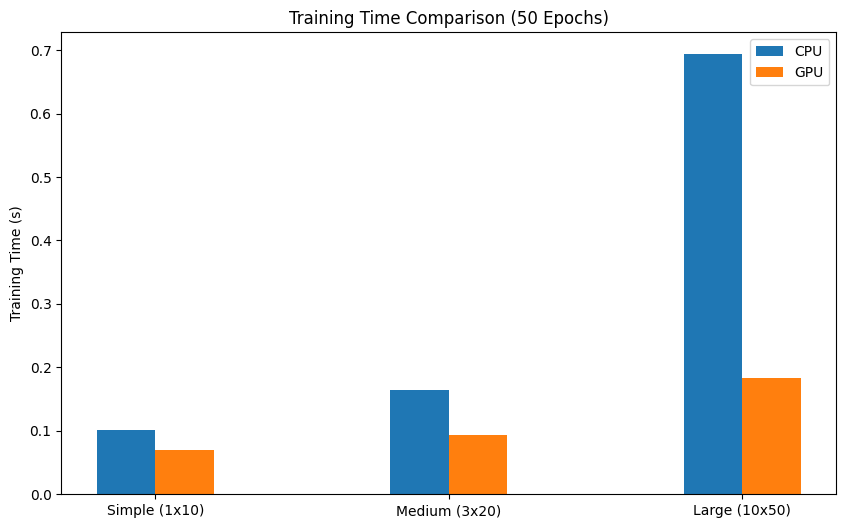

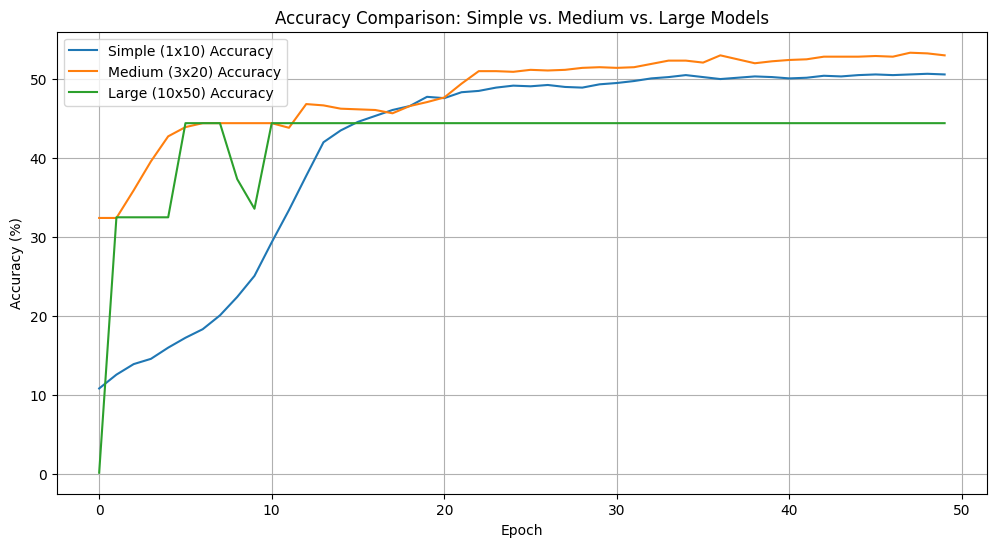

In [ ]:
labels = [c['name'] for c in configs]
cpu_train_times = [training_results[l]['cpu'] for l in labels]
gpu_train_times = [training_results[l]['gpu'] for l in labels]

x = np.arange(len(labels))
width = 0.2

# plot the training time
fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, cpu_train_times, width, label='CPU')
rects2 = ax.bar(x + width/2, gpu_train_times, width, label='GPU')

ax.set_ylabel('Training Time (s)')
ax.set_title('Training Time Comparison (50 Epochs)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

plt.show()


# Accuracy plot for each model type
plt.figure(figsize=(12, 6))
# plot each accuracy curve
for name in accuracy_results:
    plt.plot(accuracy_results[name], label=f'{name} Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy Comparison: Simple vs. Medium vs. Large Models')
plt.legend()
plt.grid(True)
plt.show()